In [24]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime, timedelta
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose

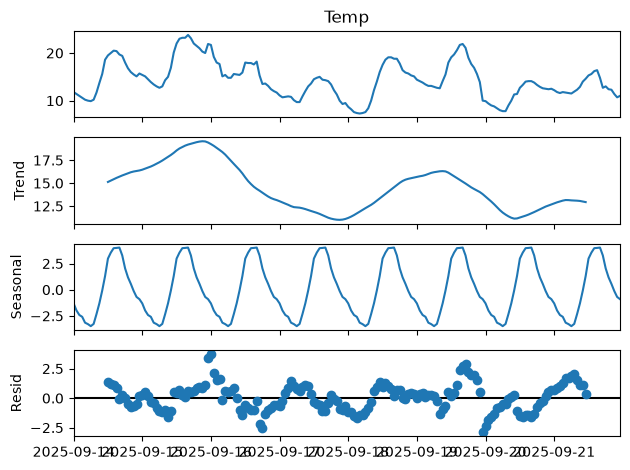

In [25]:
# Setting up for our API request
endpoint = 'https://archive-api.open-meteo.com/v1/archive'
params = {
    'latitude': -37.8136,   # Latitude for Melbourne
    'longitude': 144.9631,  # Longitude for Melbourne
    'start_date': (datetime.now() - timedelta(days=365)).strftime('%Y-%m-%d'),
    'end_date': (datetime.now() - timedelta(days=358)).strftime('%Y-%m-%d'),
    'hourly': 'temperature_2m',
    'timezone': 'Australia/Melbourne'
}

# Making request
response = requests.get(endpoint, params=params)
wdata = response.json()

# Extracting relevant data
timestamps = [datetime.fromisoformat(item) for item in wdata['hourly']['time']]
temperatures = wdata['hourly']['temperature_2m']

# Creating a pandas dataframe
wdf = pd.DataFrame({
    'Date': timestamps,
    'Temp': temperatures
})

# Setting date column as index
wdf.set_index('Date', inplace=True)

# Seasonal decomposition
decomp = seasonal_decompose(wdf['Temp'], model='additive', period=24)

# Plotting decomposed components
decomp.plot()
plt.show()

In [26]:
# ARIMA model init
arimamodel = ARIMA(wdf['Temp'], order=(1, 1, 1))
armima_fit = arimamodel.fit()

# Model summary
print(armima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                   Temp   No. Observations:                  192
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -223.600
Date:                Mon, 14 Sep 2026   AIC                            453.201
Time:                        10:24:24   BIC                            462.958
Sample:                    09-14-2025   HQIC                           457.153
                         - 09-21-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7007      0.084      8.383      0.000       0.537       0.864
ma.L1         -0.1475      0.115     -1.279      0.201      -0.374       0.079
sigma2         0.6071      0.040     15.291      0.0

/Users/oliver/COMP3742 Labs/Lab06_wutt0019/Source/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/oliver/COMP3742 Labs/Lab06_wutt0019/Source/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/oliver/COMP3742 Labs/Lab06_wutt0019/Source/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


In [27]:
# Forecasting
forecast_steps = 24
forecast = armima_fit.forecast(steps=forecast_steps)
forecast_index = pd.date_range(
    start=wdf.index[-1],
    periods=forecast_steps,
    freq='h'
)

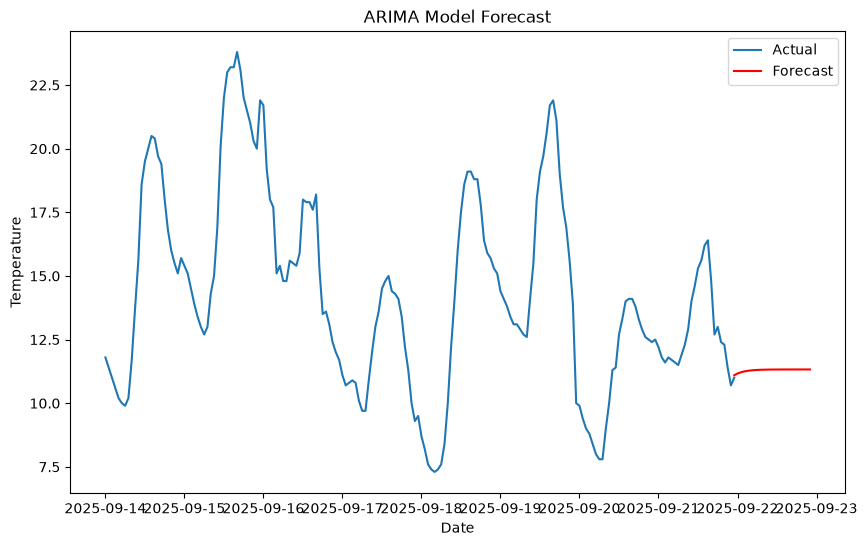

In [28]:
# Plotting the forecasts
plt.figure(figsize=(10, 6))
plt.plot(wdf['Temp'], label='Actual')
plt.plot(forecast_index, forecast, label='Forecast', color='red')
plt.title('ARIMA Model Forecast')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.legend()
plt.show()

In [29]:
# Forecast
forecast_steps = 7
forecast = armima_fit.forecast(steps=forecast_steps)
forecast_index = pd.date_range(
    start=wdf.index[-14],
    periods=forecast_steps + 1,
    inclusive='right'
)

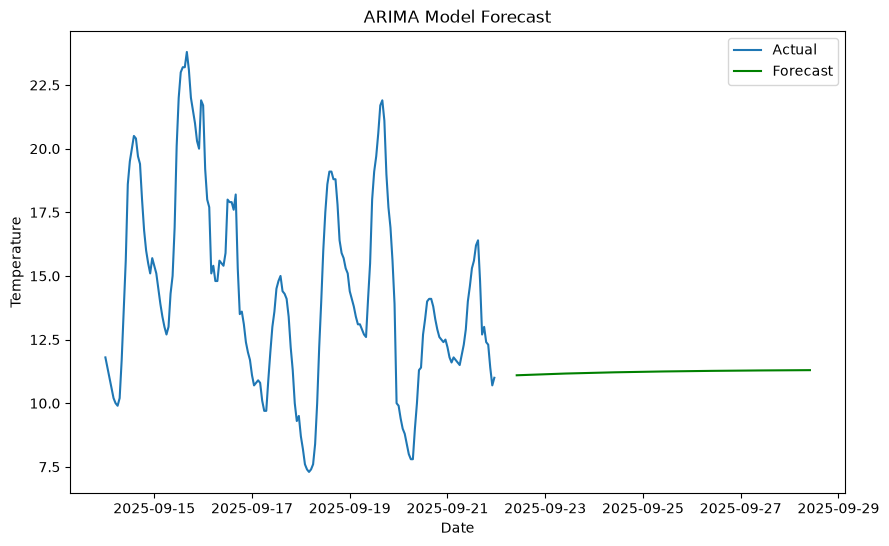

In [30]:
# Plot the forecast
plt.figure(figsize=(10, 6))
plt.plot(wdf['Temp'], label='Actual')
plt.plot(forecast_index, forecast, label='Forecast', color='green')
plt.title('ARIMA Model Forecast')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.legend()
plt.show()

In [31]:
# Train test split
train_size = int(len(wdf) * 0.8)
train, test = wdf['Temp'][:train_size], wdf['Temp'][train_size:]

# Fit model on training set
arimamodel = ARIMA(train, order=(1, 1, 1))
arimamodel_fit = arimamodel.fit()

# Make predictions
predictions = arimamodel_fit.forecast(steps=len(test))

/Users/oliver/COMP3742 Labs/Lab06_wutt0019/Source/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/oliver/COMP3742 Labs/Lab06_wutt0019/Source/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/oliver/COMP3742 Labs/Lab06_wutt0019/Source/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


In [32]:
# Compute metrics
mae = mean_absolute_error(test, predictions)
mse = mean_squared_error(test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(test, predictions)

# Print metrics
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'R^2: {r2}')

MAE: 1.733447107740588
MSE: 4.816192942333902
RMSE: 2.19458263511172
R^2: -1.2022756411898703


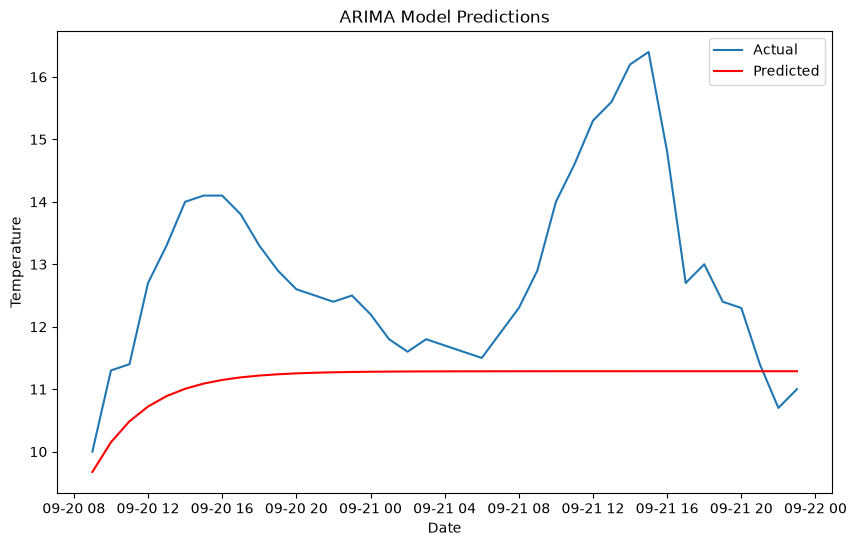

In [33]:
# Plot the predictions
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, predictions, label='Predicted', color='red')
plt.title('ARIMA Model Predictions')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.legend()
plt.show()